## Imports (+ utils: function, classes)

In [ ]:
from io import StringIO
from functools import reduce
from IPython.display import display
from tqdm import tqdm_notebook, tqdm

import numpy as np
from numpy.typing import ArrayLike
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

from genome_tools.genomic_interval import GenomicInterval
from genome_tools.data.extractors import FastaExtractor
from genome_tools.data.anndata import read_zarr_backed
from vinson.utils.helpers import replace_at
from vinson.utils.sequence_utils import one_hot_encode
from vinson.from_config import read_configs, dhs_model_from_config
from vinson.postprocessing.interpretation import ModelWrapper

from genome_tools.plotting.ideogram import read_ideogram
from genome_tools.plotting.modular_plot import IntervalPlotter
from genome_tools.plotting.modular_plot.plot_components.prediction import PredictedSignalComponent
from genome_tools.plotting.modular_plot.plot_components.basic import TrackComponent, IdeogramComponent, GencodeComponent
from genome_tools.plotting.modular_plot.plot_components.prediction import (
    AttributionsFromBatchComponent,
    AttributionsWeightedMotifHitsFromBatchComponent
)


from utils import InferenceDataset, InferenceVariantDataset, assemble_batch, score_variants_with_dhs_model

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
from matplotlib import rcParams

rcParams["axes.titlesize"] = "large"
rcParams["axes.titlepad"] = 2

rcParams["axes.linewidth"] = 0.5
rcParams["axes.labelsize"] = "medium"
rcParams["axes.labelpad"] = 1

rcParams["xtick.labelsize"] = "medium"
rcParams["ytick.labelsize"] = "medium"

rcParams["xtick.major.size"] = 2
rcParams["ytick.major.size"] = 2
rcParams["xtick.major.width"] = 0.5
rcParams["ytick.major.width"] = 0.5
rcParams["xtick.major.pad"] = 1
rcParams["ytick.major.pad"] = 1

rcParams["grid.linewidth"] = 0.5

rcParams["legend.fontsize"] = "medium"
rcParams["legend.labelspacing"] = 0.5

rcParams["font.size"] = 6

rcParams["lines.linewidth"] = 0.75


rcParams['figure.dpi'] = 300

## Set up your paths

In [31]:
# we provide with examples of files to score with our model

str_variants = """chrom\tpos\tref\talt
chr10\t11154768\tC\tG
chr3\t168285216\tC\tG
chr4\t153440582\tG\tA
chr8\t53311365\tA\tG
chr18\t5425302\tC\tT
chr4\t100185159\tT\tC
chr17\t82969252\tC\tT
chr16\t77722716\tG\tA"""

str_bed = """chr6\t3279110\t3280454
chr18\t2571385\t2572729
chr3\t64163341\t64164685
chr3\t136134521\t136135865
chr10\t114094430\t114095774
chr16\t70454157\t70455501
chr10\t106712965\t106714309
chr5\t75648340\t75649684"""




In [32]:
device = 'cuda:1'


fasta_file = '/mnt/calc/sbushuev/genomes/hg38/hg38.fa' # genome
genotype_file = '/mnt/calc/sbushuev/dhs_project/JUN29/all_variants_stats.trimmed_cols.bed.gz'
gencode_annotation_file = '/mnt/calc/sbushuev/genomes/hg38/gencode.v49.basic.annotation.sorted.gff3.gz' #'/mnt/calc/sbushuev/genomes/hg38/gencode.v49.basic.annotation.sorted.gff3.gz'
idg_path = '/mnt/calc/sbushuev/genomes/hg38/cytoBandIdeo.txt'
config_path= '/mnt/calc/homes/sbushuev/dhs_project/configs/FinalVersion/MAR06_8mln_long.yaml' # path to model's config .yaml file used to train model
checkpoint_path = '/mnt/calc/homes/sbushuev/dhs_project/checkpoints/9epochs_8mln_JUN29_best_epoch=8.ckpt' # path to .ckpt file
embeds_path = '/mnt/calc/homes/sbushuev/dhs_project/embeds/data.all.tsv'
embeds_meta_path = '/mnt/calc/homes/sbushuev/dhs_project/embeds/meta.all.tsv'

zarr_anndata_path = '/mnt/calc/sbushuev/dhs_project/anndata/reference_anndata.human.stripped_layers.zarr'

## Calculate your embeddings with motif activities

In [33]:
pass

## Load and use DNase-seq model <br>to predict density for a single sequence

In [34]:
## set up model
config = read_configs(config_path)
model = dhs_model_from_config(config, checkpoint_path = checkpoint_path).eval().to(device) #L.LightningModule

embeds = pd.read_table(embeds_path, index_col=0)
embeds_meta = pd.read_table(embeds_meta_path, index_col=0)

/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


## Get cell context aware predictions

In [35]:
## your dna sequence
half_seqlen = 1344/2
interval = GenomicInterval.from_ucsc('chr2:60495243-60495243').center.widen(half_seqlen) # select genomic loci
fasta_extr = FastaExtractor(fasta_file)
seq = fasta_extr[interval].upper() # extract sequence

##select sample and its embedding
chosen_term = 'HUDEP-2'
embed_id = embeds_meta.loc[embeds_meta.core_ontology_term == chosen_term].index.values[0] # chose one sample
embed = embeds.loc[embed_id].values

## convert to torch.Tensor and reshape to mimic batch
ohe_seq = torch.as_tensor(one_hot_encode(seq), device=device, dtype=torch.float32)[None,:, :]
embed = torch.as_tensor(embed, device=device, dtype=torch.float32)[None,:]

## get your prediction
pred = model(ohe_seq, embed)
print(pred)

tensor([[3.4821]], device='cuda:1', grad_fn=<SoftplusBackward0>)


### Calculate cell-type specific embeddings for downstream applications

In [36]:
## get model's trunk to calculate model's embedding
trunk_model = model.trunk_model # nn.Module
model_embeddings = trunk_model(ohe_seq, embed)

print(model_embeddings.shape)

torch.Size([1, 528])


## Predict tracks

In [37]:
idg = read_ideogram(idg_path)
anndata = read_zarr_backed(zarr_anndata_path)


/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing sparse_dataset from `anndata.experimental` is deprecated. Import anndata.io.sparse_dataset instead.
  warnings.warn(msg, FutureWarning)
/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/anndata/utils.py:434: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  warnings.warn(msg, FutureWarning)
/mnt/calc/sbushuev/.conda/

In [38]:
model_config = read_configs(config_path)
model_predict = dhs_model_from_config(model_config, checkpoint_path).eval()
model_wrapper = ModelWrapper(model).to(device).eval()

intervals = [GenomicInterval.from_ucsc('chr2:60495243-60495243').center]
chosen_samples = ['AG95384', 'AG80853']

base_path = 'https://regulome.altius.org/data/per_sample/' 
online_track_path = [
    base_path+ s + '/' + s + '.normalized_density.bw' 
    for s in chosen_samples]

idg_path = 'https://resources.altius.org/~sabramov/collaborations/vinson/examples/cytoBandIdeo.txt'


/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [39]:
## compose your graph

annotation_components = [
    IdeogramComponent(
        interval_key='big',
        height=0.1, # height, handled by IntervalPlotter, by default, in inches,
        margins=0
    ),
    GencodeComponent(
        interval_key='big',
        height=0.03,
        margins=(0, 0.02)
    )] 
track_components = [
   [
       TrackComponent(
        name=f'TrueSignalComponent_{s}',
        signal_file = online_track_path[idx],
        interval_key='med',
        color='tab:blue',
        height=0.5,
        margins=(0.05,0.1)),
        PredictedSignalComponent(
        name=f'PredictedSignalComponent_{s}',
        interval_key='med',
        sample_id=s,
        color='tab:orange',
        height=0.5,
        margins=(0.05,0.1))
        ]
        
            for idx, s in enumerate(chosen_samples)
         ]

plot_components = annotation_components + sum(track_components, [])

interval_plotter = IntervalPlotter(
    plot_components=plot_components,
    anndata=anndata,
    model_config=model_config,
    model_wrapper=model_wrapper,
    fasta_file=fasta_file,
    ideogram_data=idg,
    gencode_annotation_file=gencode_annotation_file,
)

Found overlapping component loader kwargs:
Argument 'signal_file' used by: TrueSignalComponent_AG95384, PredictedSignalComponent_AG95384, TrueSignalComponent_AG80853, PredictedSignalComponent_AG80853
Argument 'model_wrapper' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853
Argument 'interp1d_kind' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853
Argument 'sample_id' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853
Argument 'anndata' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853
Argument 'fasta_file' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853
Argument 'genotype_file' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853
Argument 'step' used by: PredictedSignalComponent_AG95384, PredictedSignalComponent_AG80853


In [40]:
seqlen = 4000
plotter_data_bundle = []

for reg in intervals:
    reg = reg.widen(seqlen)
    plotter_data = interval_plotter.get_interval_data(
        interval={
            'small': reg,
            'big': reg,
            'med': reg,
        },
        step=20,
    )
    plotter_data_bundle.append(plotter_data)

Loading data: 100%|██████████| 6/6 [00:09<00:00,  1.53s/it]


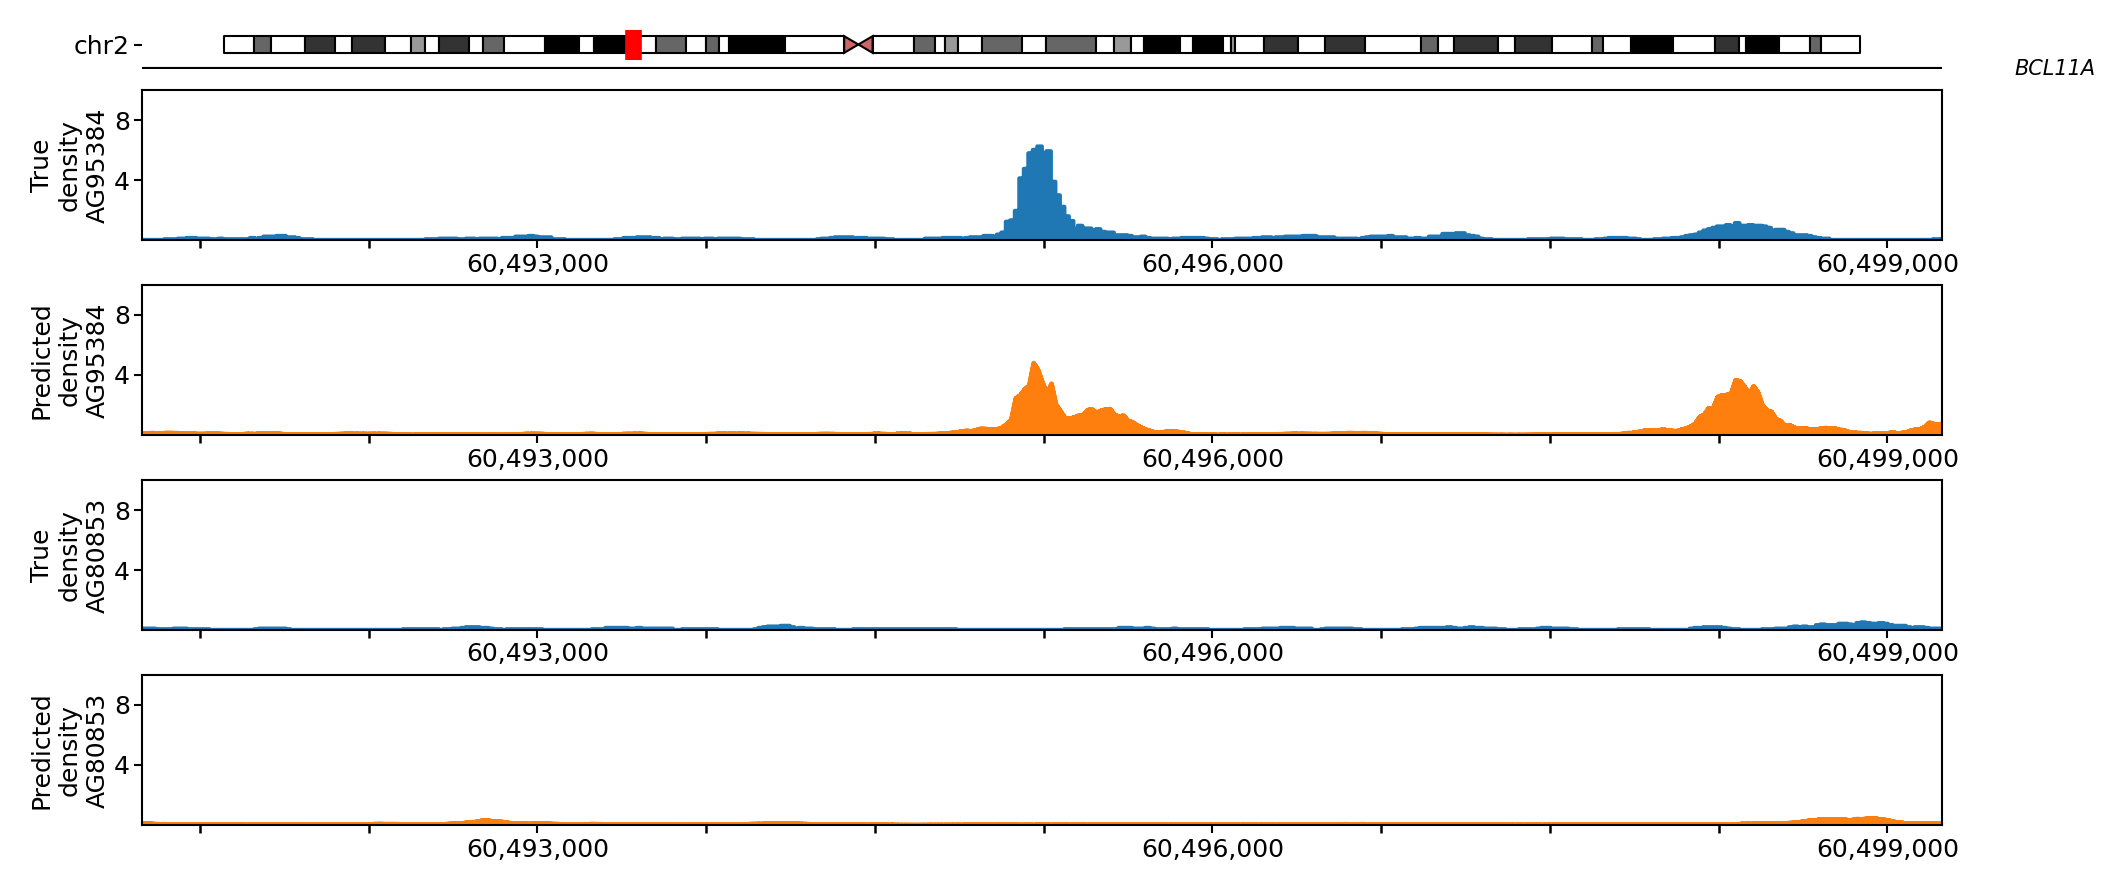

In [41]:
import matplotlib.pyplot as plt
for plotter_data in plotter_data_bundle:
    axes = interval_plotter.plot_interval(plotter_data, fig_width=6)

    for idx, ax in enumerate(axes[2:]):
        ax.set_ylim(0,10)
        sample_idx = idx//2

        if idx %2 == 0:
            ax.set_ylabel(f'True\ndensity\n{chosen_samples[sample_idx]}')
        else:
            ax.set_ylabel(f'Predicted\ndensity\n{chosen_samples[sample_idx]}')

plt.show()

## Dissect regulatory grammar underlying chromatin accessibility 

In [42]:
motif_metadata_path = 'https://resources.altius.org/~sabramov/collaborations/vinson/examples/motifs_meta.tsv'
motif_annotations_path = '/mnt/calc/homes/sbushuev/dhs_project/examples/moods_scans_ref.merged.sorted.bed.gz'
motif_metadata = pd.read_table('/mnt/calc/homes/sbushuev/dhs_project/examples/motifs_meta.tsv', index_col=0)

motif_metadata = pd.read_table(motif_metadata_path, index_col=0)

### temp
motif_metadata['pfm'] = motif_metadata['pfm'].str.replace('/home/jvierstra/public_html/', 'https://resources.altius.org/~jvierstra/')
motif_metadata['pfm'] = motif_metadata['pfm'].str.replace('projects/projects', 'projects')

# motif_metadata.head()


In [43]:
model_config = read_configs(config_path)
model_predict = dhs_model_from_config(model_config, checkpoint_path).to('cpu')
model_wrapper = ModelWrapper(model).eval().to(device) #.to('cuda:1')

chosen_sample = 'AG95384'
interval = GenomicInterval.from_ucsc('chr14:72685616-72686960')

/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [44]:
plot_components = [
    IdeogramComponent(
        interval_key='big', # interval_key for which the component should be ploted
        height=0.03, # height, handled by IntervalPlotter, by default, in inches,
        margins=0,
    ),
    GencodeComponent(
        interval_key='big',
        height=0.05,
        margins=(0, 0.02) # margins: either one number or a tuple of two: top and bottom
    ),
    PredictedSignalComponent(
                name=f'PredictedSignalComponent_{chosen_sample}',
                interval_key='big',
                sample_id=chosen_sample,
                color='tab:orange',
                height=0.1,
                margins=(0, 0.05),
            ),

    AttributionsFromBatchComponent(
        interval_key='small',
        height=0.06,
        margins=0,
        n_shuffles=100,
    ),
    AttributionsWeightedMotifHitsFromBatchComponent(
        interval_key='small',
        height=0.06,
        margins=0,
        n_shuffles=100,
        motif_annotations_path=motif_annotations_path
    )
    
]

interval_plotter = IntervalPlotter(
    plot_components=plot_components,
    ideogram_data=idg,
    model_wrapper=model_wrapper,
    motif_meta=motif_metadata,
    fasta_file=fasta_file,
    gencode_annotation_file=gencode_annotation_file,
)

Found overlapping component loader kwargs:
Argument 'model_wrapper' used by: PredictedSignalComponent_AG95384, AttributionsFromBatchComponent, AttributionsWeightedMotifHitsFromBatchComponent
Argument 'sample_id' used by: PredictedSignalComponent_AG95384, AttributionsFromBatchComponent
Argument 'anndata' used by: PredictedSignalComponent_AG95384, AttributionsFromBatchComponent
Argument 'fasta_file' used by: PredictedSignalComponent_AG95384, AttributionsFromBatchComponent
Argument 'genotype_file' used by: PredictedSignalComponent_AG95384, AttributionsFromBatchComponent
Argument 'print_convergence_deltas' used by: AttributionsFromBatchComponent, AttributionsWeightedMotifHitsFromBatchComponent
Argument 'n_shuffles' used by: AttributionsFromBatchComponent, AttributionsWeightedMotifHitsFromBatchComponent
Argument 'random_state' used by: AttributionsFromBatchComponent, AttributionsWeightedMotifHitsFromBatchComponent
Argument 'batch' used by: AttributionsFromBatchComponent, AttributionsWeighte

In [45]:
interval_dict = {
    'big': interval.zoom(-7),
    'small': interval.zoom(10)
}

annotation_regions = [
    GenomicInterval.from_ucsc('chr14:72686255-72686281'),
    GenomicInterval.from_ucsc('chr14:72686328-72686354'),
] # regions where to look for motif scans


plotter_data = interval_plotter.get_interval_data(
    interval_dict,
    batch=assemble_batch(
        'AG95384',
        interval=interval,
        embeddings=anndata.obsm['motif_embeddings'],
        fasta=fasta_file
    ),
    # signal_file=human_anndata.obs.loc['AG95384', 'normalized_density_bw'],
    anndata=anndata,
    annotation_regions=annotation_regions,

)

Loading data:   0%|          | 0/5 [00:00<?, ?it/s]

Loading data:  60%|██████    | 3/5 [00:00<00:00,  3.77it/s]/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:745: RuntimeWarning: Convergence deltas too high: tensor([2.6687, 1.6386, 1.5074, 0.7701, 0.2544, 1.7488, 1.6378, 2.0120, 1.8180,
        1.7784, 0.9756, 0.7902, 1.7993, 1.7969, 1.5316, 1.8746, 2.7008, 1.0188,
        1.9034, 1.6741, 2.0415, 2.4603, 1.8229, 2.5644, 2.1878, 1.5020, 1.9676,
        1.5144, 2.2348, 2.1788, 1.5486, 1.9049], device='cuda:1',
       grad_fn=<AbsBackward0>)
  warnings.warn("Convergence deltas too high: " +
/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:745: RuntimeWarning: Convergence deltas too high: tensor([1.7442, 2.4414, 2.0885, 1.9067, 1.6586, 1.4173, 1.0936, 1.9355, 2.4195,
        2.2652, 1.6683, 1.7601, 2.3671, 1.3640, 1.4911, 1.5354, 2.3789, 1.8200,
        1.9669, 1.6482, 2.4189, 1.7711, 1.7544, 2.5411, 1.5954, 2.1562, 1.4721,
        2.0429, 1.61

PlotComponent AttributionsWeightedMotifHitsFromBatchComponent returned multiple axes. Using the first one when adding a connector.
PlotComponent AttributionsWeightedMotifHitsFromBatchComponent returned multiple axes. Using the first one when adding a connector.
PlotComponent AttributionsWeightedMotifHitsFromBatchComponent returned multiple axes. Using the first one when adding a connector.
PlotComponent AttributionsWeightedMotifHitsFromBatchComponent returned multiple axes. Using the first one when adding a connector.


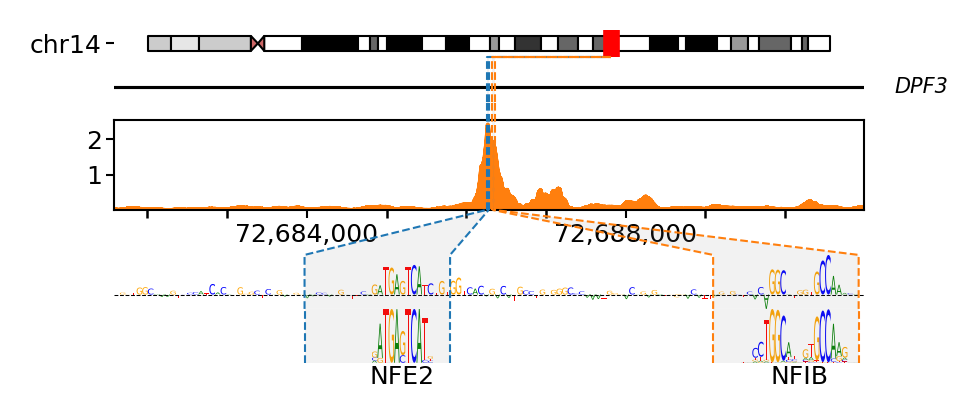

In [46]:
axes = interval_plotter.plot_interval(plotter_data, height_scale=3)

for i, region in enumerate(annotation_regions):
    interval_plotter.plot_connector(
        axes,
        interval=region,
        lw=0,
        type='area',
        extend_to_bottom=True,
        alpha=0.1
    )

    interval_plotter.plot_connector(
        axes,
        interval=region,
        ls='--',
        c=f'C{i}',
        lw=0.5,
        type='line',
        extend_to_bottom=True
    )

## Calculate cell-type context aware <br>model's embeddings of genetic loci

In [47]:
config = read_configs(config_path)
embeds_df = pd.read_table(embeds_path, index_col=0)
embeds_meta = pd.read_table(embeds_meta_path, index_col=0)
bed_df = pd.read_table(StringIO(str_bed), header=None,
                       names=['chrom', 'start', 'end'])
bed_df.columns = ['chrom', 'start', 'end']

model = dhs_model_from_config(config, checkpoint_path = checkpoint_path).eval().to(device)
trunk_model = model.trunk_model

/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [48]:
## Select samples
selected_samples = ['AG3897']
embeds_df = embeds_df.loc[selected_samples]

In [49]:
dataset = InferenceDataset(bed_df, embeds_df, fasta_file) 
dataloader = DataLoader(dataset, 
                        batch_size=256, 
                        num_workers=1, 
                        pin_memory=True, 
                        shuffle=False)

In [50]:
lst_embeds = []

with torch.no_grad():    
    for batch in tqdm_notebook(dataloader):
        seq, seq_revcomp = batch['seq'].to(device), batch['seq_revcomp'].to(device)
        embeds = batch['embed'].to(device)

        model_embeds = (trunk_model(seq, embeds) + trunk_model(seq_revcomp, embeds)) / 2

        lst_embeds.append(model_embeds.cpu().numpy())

model_embeds = np.concatenate(lst_embeds)

/tmp/ipykernel_3206549/2104353720.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for batch in tqdm_notebook(dataloader):


  0%|          | 0/1 [00:00<?, ?it/s]

In [51]:
meta = dataset.prepare_meta()
display(meta.head())
print(model_embeds.shape)

,chrom,start,end,shift,embed_id
0,chr6,3279110,3280454,0,AG3897
1,chr18,2571385,2572729,0,AG3897
2,chr3,64163341,64164685,0,AG3897
3,chr3,136134521,136135865,0,AG3897
4,chr10,114094430,114095774,0,AG3897


(8, 528)


### You can predict whatever you want with genotype injecting

In [52]:
dataset_with_genotype = InferenceDataset(bed_df, embeds_df, 
                                         fasta_file, embed_meta_df=embeds_meta,
                                         genotype_file=genotype_file)


## Predict effect of variants <br>in the context of different cell-types

In [53]:
config = read_configs(config_path)
embeds_df = pd.read_table(embeds_path, index_col=0)
embeds_meta = pd.read_table(embeds_meta_path)
variants = pd.read_table(StringIO(str_variants))

model = dhs_model_from_config(config, checkpoint_path = checkpoint_path).eval().to(device)


/mnt/calc/sbushuev/.conda/envs/dhs_env/lib/python3.12/site-packages/lightning/fabric/utilities/cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


In [54]:
## Select samples, shifts to score
shifts = [-10, 0, 10]
selected_samples = ['AG80837', 'AG80853']
embeds_df = embeds_df.loc[selected_samples]
## set up kwargs for dataloader
dataloader_kwargs = dict(batch_size=256, 
                        num_workers=16, 
                        pin_memory=True, 
                        shuffle=False)

In [62]:
out_df = score_variants_with_dhs_model(variants, embeds_df, 
                              fasta_file, shifts, model,
                              dataloader_kwargs=dataloader_kwargs,
                              device=device)
out_df.head()

  0%|          | 0/1 [00:00<?, ?it/s]

,chrom,pos,ref,alt,shift,embed_id,var_id,vinson.ref_score,vinson.alt_score
0,chr10,11154768,C,G,-10,AG80837,chr10_11154768_C_G,0.016555,0.017524
1,chr3,168285216,C,G,-10,AG80837,chr3_168285216_C_G,0.078363,0.079103
2,chr4,153440582,G,A,-10,AG80837,chr4_153440582_G_A,0.564792,0.500176
3,chr8,53311365,A,G,-10,AG80837,chr8_53311365_A_G,0.060304,0.063670
4,chr18,5425302,C,T,-10,AG80837,chr18_5425302_C_T,0.111662,0.106978


### Aggregate your predictions however you want: across samples, across shifts, etc

In [63]:
out_df['vinson.ref_score'] = np.log(out_df['vinson.ref_score'])
out_df['vinson.alt_score'] = np.log(out_df['vinson.alt_score'])
aggr_df = out_df.groupby(['chrom', 'pos', 'ref', 'alt','embed_id' ,'var_id'], observed=True ).agg(
    {'vinson.ref_score':'mean',
     'vinson.alt_score':'mean'}
).reset_index()
aggr_df['vinson.ref_score'] = np.exp(aggr_df['vinson.ref_score'])
aggr_df['vinson.alt_score'] = np.exp(aggr_df['vinson.alt_score'])

aggr_df.head()

,chrom,pos,ref,alt,embed_id,var_id,vinson.ref_score,vinson.alt_score
0,chr10,11154768,C,G,AG80837,chr10_11154768_C_G,0.017222,0.018066
1,chr10,11154768,C,G,AG80853,chr10_11154768_C_G,0.020362,0.021390
2,chr16,77722716,G,A,AG80837,chr16_77722716_G_A,1.239882,1.324736
3,chr16,77722716,G,A,AG80853,chr16_77722716_G_A,0.741653,0.814745
4,chr17,82969252,C,T,AG80837,chr17_82969252_C_T,0.429942,0.456354
